# BFOR 516 – Advanced Data Analytics for Cyber
## Lab: Recurrent Neural Networks — Microsoft (MSFT) Stock Price Prediction
**Instructor:** Srishti Gupta, Ph.D.  
**Dataset:** NASDAQ Historical Data — Microsoft Corporation (MSFT)  
**Date:** April 2026

---

### Lab Objective
Build a Recurrent Neural Network (RNN) from scratch using TensorFlow/Keras to predict Microsoft stock closing prices. We follow the same workflow demonstrated in class with Apple (AAPL) stock data, applying it to the MSFT dataset.

### AI Disclosure
**Antigravity AI (Google DeepMind)** was used as a pair-programming assistant to help scaffold this notebook's structure, suggest best-practice preprocessing steps (MinMaxScaler, sequence windowing), and guide architecture decisions (SimpleRNN → LSTM comparison). All code was reviewed, understood, and is submitted with the student's own analysis and interpretation. AI output was not copied verbatim — it was evaluated, modified, and integrated intentionally.

---

### Workflow Overview
1. Import libraries
2. Load & explore the MSFT dataset
3. Preprocess & normalize data
4. Create time-step sequences (sliding window)
5. Build the RNN model
6. Train the model
7. Evaluate & visualize predictions
8. Generate a future price forecast
9. Analysis & conclusions

---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")

TensorFlow version : 2.21.0
NumPy version      : 2.4.1
Pandas version     : 2.3.3


---
## Step 2 — Load & Explore the Dataset

In [2]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
DATA_PATH = r"HistoricalData_Microsoft.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head(10)

Shape: (124, 6)


,Date,Close/Last,Volume,Open,High,Low
0,03/11/2026,$404.88,25512140,$405.57,$409.01,$401.59
1,03/10/2026,$405.76,31706380,$410.03,$410.20,$402.93
2,03/09/2026,$409.41,30131850,$404.915,$410.21,$403.50
3,03/06/2026,$408.96,31123860,$409.20,$413.05,$408.5101
4,03/05/2026,$410.68,39001320,$404.42,$411.61,$404.40
5,03/04/2026,$405.20,35807990,$401.265,$411.0326,$400.31
6,03/03/2026,$403.93,38199210,$393.14,$406.70,$392.67
7,03/02/2026,$398.55,35474910,$392.855,$401.19,$390.63
8,02/27/2026,$392.74,51367200,$390.88,$396.82,$389.88
9,02/26/2026,$401.72,34405870,$404.71,$407.49,$398.74


In [3]:
# ── Basic info ────────────────────────────────────────────────────────────────
print("Columns:", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)
print("\nMissing values:")
print(df_raw.isnull().sum())

Columns: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

Data types:
Date          object
Close/Last    object
Volume         int64
Open          object
High          object
Low           object
dtype: object

Missing values:
Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64


In [4]:
print("\nDescriptive Statistics (raw):")
df_raw.describe(include='all')


Descriptive Statistics (raw):


,Date,Close/Last,Volume,Open,High,Low
count,124,124,1.240000e+02,124,124,124
unique,124,123,NaN,124,124,122
top,03/11/2026,$483.47,NaN,$405.57,$409.01,$475.86
freq,1,2,NaN,1,1,2
mean,NaN,NaN,2.795272e+07,NaN,NaN,NaN
std,NaN,NaN,1.491522e+07,NaN,NaN,NaN
min,NaN,NaN,5.855880e+06,NaN,NaN,NaN
25%,NaN,NaN,1.886896e+07,NaN,NaN,NaN
50%,NaN,NaN,2.459818e+07,NaN,NaN,NaN
75%,NaN,NaN,3.403432e+07,NaN,NaN,NaN


**Observation:** Prices are stored as strings prefixed with `$` (e.g., `$404.88`). We need to strip the dollar sign and convert to `float`. Dates are strings in `MM/DD/YYYY` format and should be parsed as `datetime` objects.

---
## Step 3 — Preprocess & Normalize Data

In [5]:
# ── Clean & type-cast ─────────────────────────────────────────────────────────
df = df_raw.copy()

# Parse dates and sort chronologically (oldest → newest)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Strip '$' from price columns and convert to float
price_cols = ['Close/Last', 'Open', 'High', 'Low']
for col in price_cols:
    df[col] = df[col].str.replace('$', '', regex=False).astype(float)

# Rename 'Close/Last' for clarity
df.rename(columns={'Close/Last': 'Close'}, inplace=True)

print("Cleaned DataFrame — first 5 rows:")
print(df.head())
print("\nDate range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("Total trading days:", len(df))

Cleaned DataFrame — first 5 rows:
        Date   Close    Volume    Open    High     Low
0 2025-09-12  509.90  23624880  506.65  512.55  503.85
1 2025-09-15  515.36  17143790  508.79  515.47  507.00
2 2025-09-16  509.04  19711920  516.88  517.23  508.60
3 2025-09-17  510.02  15816590  510.62  511.29  505.93
4 2025-09-18  508.45  18913700  511.49  513.07  507.66

Date range: 2025-09-12 → 2026-03-11
Total trading days: 124


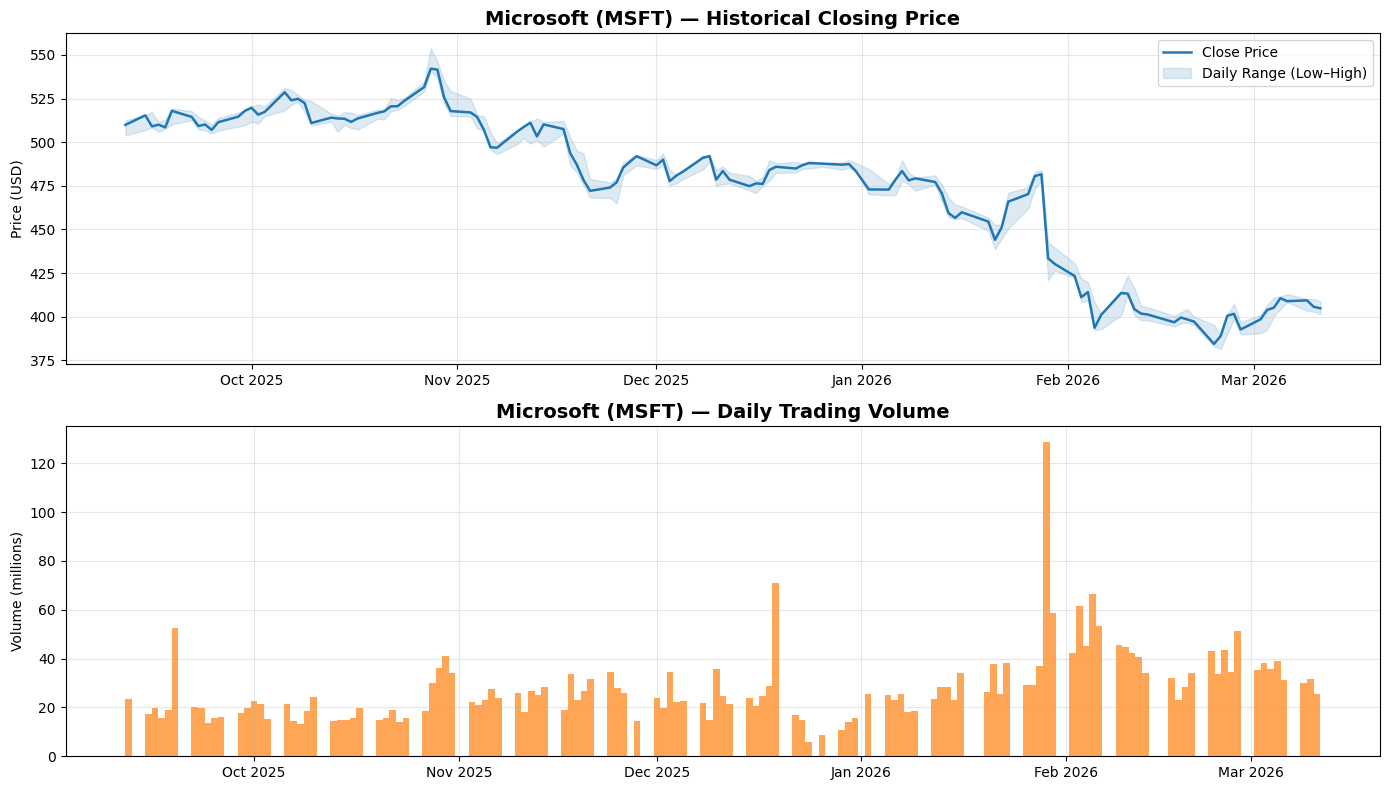

Figure saved as msft_eda.png


In [6]:
# ── Visualize raw closing price ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Closing price
axes[0].plot(df['Date'], df['Close'], color='#1f77b4', linewidth=1.8, label='Close Price')
axes[0].fill_between(df['Date'], df['Low'], df['High'], alpha=0.15, color='#1f77b4', label='Daily Range (Low–High)')
axes[0].set_title('Microsoft (MSFT) — Historical Closing Price', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Volume'] / 1e6, color='#ff7f0e', alpha=0.7, width=1.0)
axes[1].set_title('Microsoft (MSFT) — Daily Trading Volume', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume (millions)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('msft_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_eda.png")

In [7]:
# ── Feature selection & normalization ────────────────────────────────────────
# We use the closing price as the target variable (univariate RNN)
close_prices = df['Close'].values.reshape(-1, 1)

# MinMaxScaler scales values to [0, 1] — required for RNN convergence
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)

print("Original price range: ${:.2f} – ${:.2f}".format(
    float(close_prices.min()), float(close_prices.max())))
print("Scaled price range : {:.4f} – {:.4f}".format(
    float(scaled_prices.min()), float(scaled_prices.max())))

Original price range: $384.47 – $542.07
Scaled price range : 0.0000 – 1.0000


---
## Step 4 — Create Time-Step Sequences (Sliding Window)

RNNs learn from *sequences*. We use a **sliding window** of `look_back` days to predict the next day's closing price.

```
Window:  [t-N, t-N+1, ..., t-1]  →  predict  [t]
```

In [8]:
def create_sequences(data, look_back=10):
    """
    Converts a time series into overlapping sequences.
    
    Parameters
    ----------
    data      : 2-D array, shape (n_samples, 1)
    look_back : int, number of past days used as features
    
    Returns
    -------
    X : shape (n_samples - look_back, look_back, 1)
    y : shape (n_samples - look_back,)
    """
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)


LOOK_BACK = 10   # use the past 10 trading days to predict the next day

X, y = create_sequences(scaled_prices, look_back=LOOK_BACK)

# Reshape X to (samples, timesteps, features) — required by Keras RNN layers
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Sequence dataset: X.shape={X.shape}, y.shape={y.shape}")

Sequence dataset: X.shape=(114, 10, 1), y.shape=(114,)


In [9]:
# ── Train / Test split (80 / 20) ─────────────────────────────────────────────
TRAIN_RATIO = 0.80
split_idx = int(len(X) * TRAIN_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 91
Testing  samples : 23


---
## Step 5 — Build the RNN Model

We build a **SimpleRNN** architecture first (to match the in-class demo), then an **LSTM** variant for comparison.  

| Layer | Type | Units | Notes |
|---|---|---|---|
| 1 | SimpleRNN | 64 | `tanh` activation, returns full sequence |
| 2 | Dropout | — | 20% dropout to reduce overfitting |
| 3 | SimpleRNN | 32 | `tanh` activation, final hidden state only |
| 4 | Dense | 1 | Linear activation — regression output |

In [10]:
def build_simple_rnn(look_back, units_1=64, units_2=32, dropout_rate=0.2):
    model = Sequential([
        SimpleRNN(units_1, activation='tanh', return_sequences=True,
                  input_shape=(look_back, 1), name='RNN_1'),
        Dropout(dropout_rate, name='Dropout_1'),
        SimpleRNN(units_2, activation='tanh', return_sequences=False, name='RNN_2'),
        Dropout(dropout_rate, name='Dropout_2'),
        Dense(1, activation='linear', name='Output')
    ], name='SimpleRNN_Model')
    
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model


rnn_model = build_simple_rnn(LOOK_BACK)
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ RNN_1 (SimpleRNN)               │ (None, 10, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN_2 (SimpleRNN)               │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 6 — Train the Model

In [11]:
# ── Early stopping prevents overfitting ───────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

EPOCHS    = 200
BATCH     = 8

history = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/200


 1/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.2538 - mae: 0.4391

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.2073 - mae: 0.3691 - val_loss: 0.0950 - val_mae: 0.2831


Epoch 2/200


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1236 - mae: 0.2761

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0316 - mae: 0.1306

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0211 - mae: 0.1139 - val_loss: 0.0132 - val_mae: 0.0905


Epoch 47: early stopping


Restoring model weights from the end of the best epoch: 32.



Training stopped at epoch 47

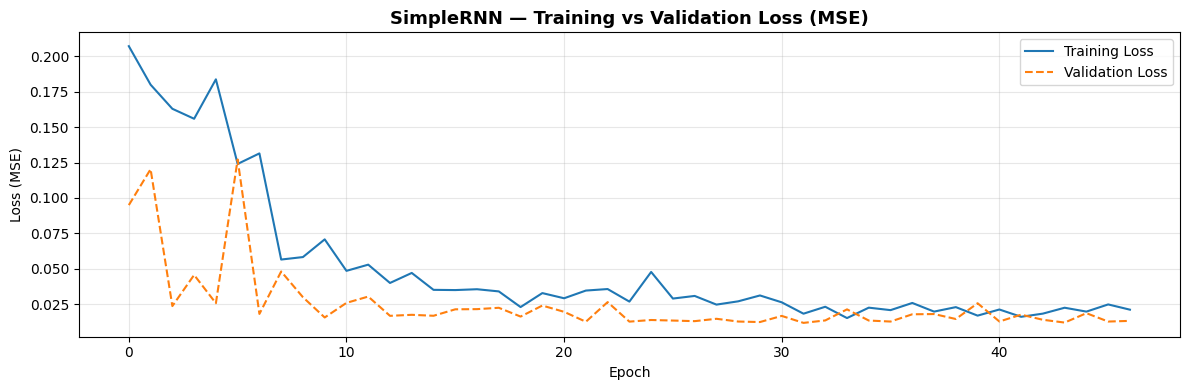

Figure saved as msft_training_loss.png


In [12]:
# ── Plot training & validation loss ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'],     label='Training Loss',   color='#1f77b4')
ax.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linestyle='--')
ax.set_title('SimpleRNN — Training vs Validation Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('msft_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_training_loss.png")

---
## Step 7 — Evaluate & Visualize Predictions

In [13]:
# ── Predict and inverse-transform back to USD ─────────────────────────────────
y_pred_scaled = rnn_model.predict(X_test)

# Inverse transform (scale back to original price range)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Align to original dates
test_dates = df['Date'].values[split_idx + LOOK_BACK : split_idx + LOOK_BACK + len(y_test)]

print(f"Test predictions shape : {y_pred.shape}")
print(f"Actual values shape    : {y_actual.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


Test predictions shape : (23, 1)
Actual values shape    : (23, 1)


In [14]:
# ── Error metrics ─────────────────────────────────────────────────────────────
mse  = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print("=" * 40)
print("  SimpleRNN — Test Set Metrics")
print("=" * 40)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAE  : ${mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

  SimpleRNN — Test Set Metrics
  MSE  : 549.3877
  RMSE : $23.44
  MAE  : $21.00
  MAPE : 5.21%


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


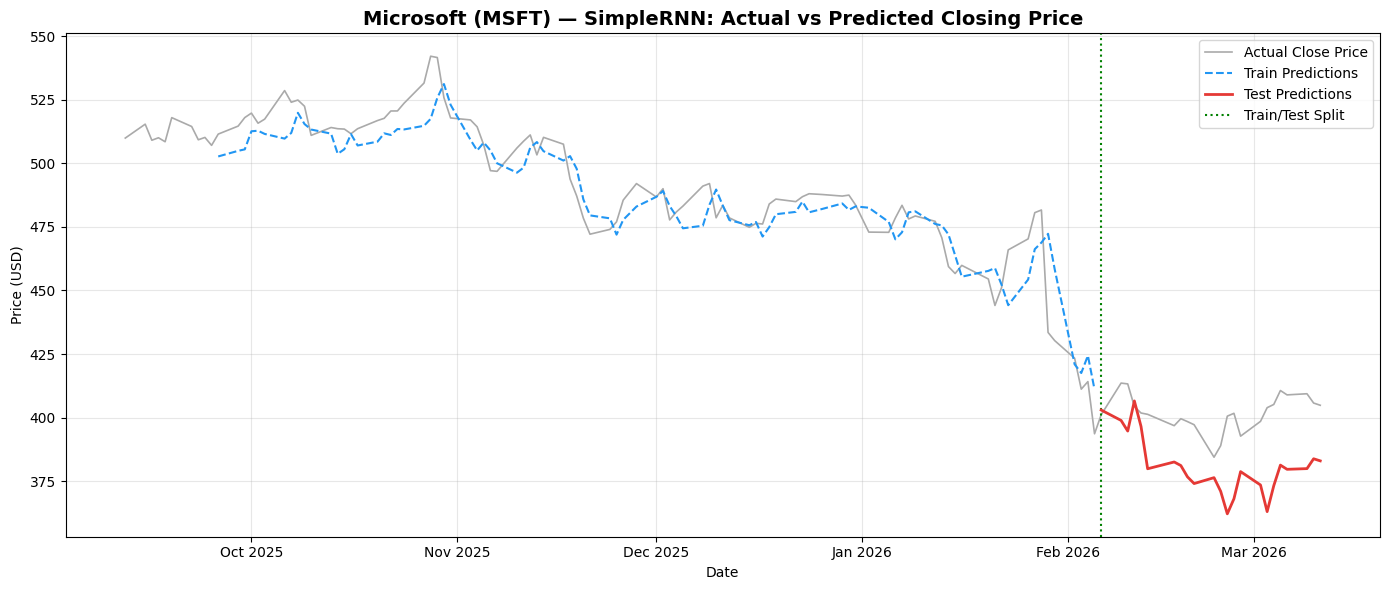

Figure saved as msft_rnn_predictions.png


In [15]:
# ── Full timeline prediction plot ─────────────────────────────────────────────
# Reconstruct full train predictions for visualization
y_train_pred_scaled = rnn_model.predict(X_train)
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

train_dates = df['Date'].values[LOOK_BACK : LOOK_BACK + len(y_train)]

fig, ax = plt.subplots(figsize=(14, 6))

# Actual prices (full period)
ax.plot(df['Date'], df['Close'], color='#aaaaaa', linewidth=1.2,
        label='Actual Close Price', zorder=1)

# Train predictions
ax.plot(train_dates, y_train_pred, color='#2196F3', linewidth=1.5,
        linestyle='--', label='Train Predictions', zorder=2)

# Test predictions
ax.plot(test_dates, y_pred, color='#E53935', linewidth=2.0,
        label='Test Predictions', zorder=3)

# Vertical line separating train / test
ax.axvline(x=df['Date'].values[split_idx + LOOK_BACK], color='green',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title('Microsoft (MSFT) — SimpleRNN: Actual vs Predicted Closing Price',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('msft_rnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_rnn_predictions.png")

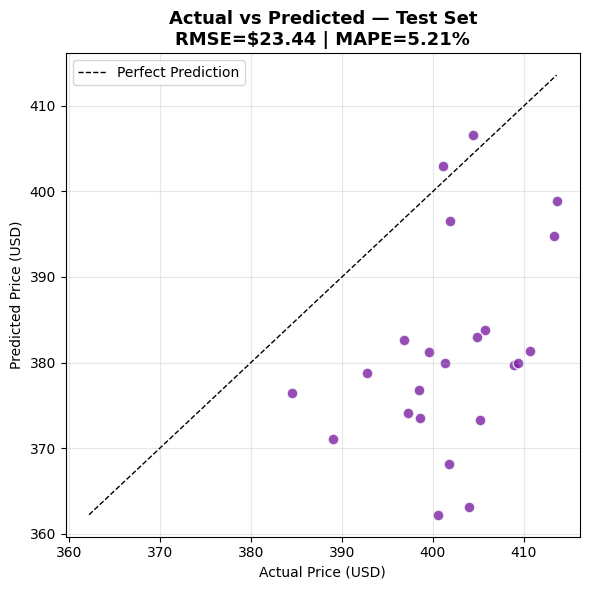

Figure saved as msft_scatter.png


In [16]:
# ── Actual vs Predicted scatter ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_actual, y_pred, alpha=0.8, color='#7b1fa2', edgecolors='white', s=60)
line_min = min(y_actual.min(), y_pred.min())
line_max = max(y_actual.max(), y_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], 'k--', linewidth=1, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted — Test Set\nRMSE=${rmse:.2f} | MAPE={mape:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('msft_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_scatter.png")

---
## Step 8 — LSTM Variant (Extended Analysis)

LSTM (Long Short-Term Memory) addresses the **vanishing gradient problem** in SimpleRNNs by using gated memory cells. We train an LSTM on the same data and compare performance.

In [17]:
def build_lstm(look_back, units_1=64, units_2=32, dropout_rate=0.2):
    model = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=(look_back, 1), name='LSTM_1'),
        Dropout(dropout_rate, name='Dropout_1'),
        LSTM(units_2, return_sequences=False, name='LSTM_2'),
        Dropout(dropout_rate, name='Dropout_2'),
        Dense(1, activation='linear', name='Output')
    ], name='LSTM_Model')
    
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model


lstm_model = build_lstm(LOOK_BACK)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop_lstm = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)

print(f"\nLSTM training stopped at epoch {len(history_lstm.history['loss'])}")

Epoch 1/200


 1/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.7695 - mae: 0.8709

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.3743 - mae: 0.5808 - val_loss: 0.0251 - val_mae: 0.1325


Epoch 2/200


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0999 - mae: 0.3003

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - mae: 0.0935

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0111 - mae: 0.0847 - val_loss: 0.0420 - val_mae: 0.1742


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 1.



LSTM training stopped at epoch 16

In [19]:
# ── LSTM predictions & metrics ────────────────────────────────────────────────
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)

mse_lstm  = mean_squared_error(y_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm  = mean_absolute_error(y_actual, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_actual - y_pred_lstm) / y_actual)) * 100

print("=" * 40)
print("  LSTM — Test Set Metrics")
print("=" * 40)
print(f"  MSE  : {mse_lstm:.4f}")
print(f"  RMSE : ${rmse_lstm:.2f}")
print(f"  MAE  : ${mae_lstm:.2f}")
print(f"  MAPE : {mape_lstm:.2f}%")
print("=" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


  LSTM — Test Set Metrics
  MSE  : 300.4501
  RMSE : $17.33
  MAE  : $15.40
  MAPE : 3.86%


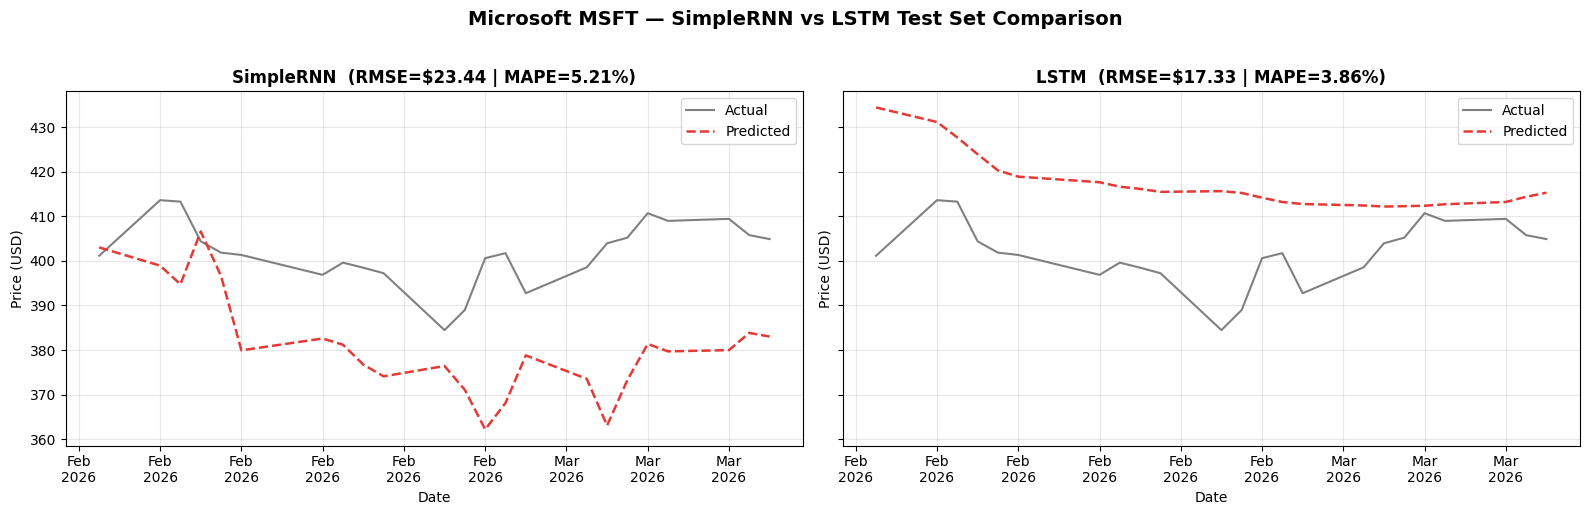

Figure saved as msft_comparison.png


In [20]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, pred, title, rmse_val, mape_val in [
    (axes[0], y_pred,      'SimpleRNN', rmse,      mape),
    (axes[1], y_pred_lstm, 'LSTM',      rmse_lstm, mape_lstm)
]:
    ax.plot(test_dates, y_actual, color='gray', linewidth=1.5, label='Actual')
    ax.plot(test_dates, pred,     color='#E53935', linewidth=1.8, linestyle='--', label='Predicted')
    ax.set_title(f'{title}  (RMSE=${rmse_val:.2f} | MAPE={mape_val:.2f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Microsoft MSFT — SimpleRNN vs LSTM Test Set Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('msft_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_comparison.png")

---
## Step 9 — Future Price Forecast (5-Day Lookahead)

Using the best model and the **most recent `LOOK_BACK` days**, we recursively generate a 5-trading-day forecast.

In [21]:
def forecast_future(model, scaled_data, look_back, n_days=5, scaler=None):
    """
    Recursive n-step-ahead forecast.
    Each new prediction is appended to the input window for the next step.
    """
    last_window = scaled_data[-look_back:].reshape(1, look_back, 1)
    preds_scaled = []
    
    for _ in range(n_days):
        pred = model.predict(last_window, verbose=0)
        preds_scaled.append(pred[0, 0])
        # Shift window forward by 1 and append the new prediction
        last_window = np.roll(last_window, -1, axis=1)
        last_window[0, -1, 0] = pred[0, 0]
    
    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    if scaler:
        return scaler.inverse_transform(preds_scaled)
    return preds_scaled


# Use the better model (compare RMSE)
best_model = lstm_model if rmse_lstm < rmse else rnn_model
best_label  = 'LSTM' if rmse_lstm < rmse else 'SimpleRNN'
print(f"Best model selected: {best_label}")

FORECAST_DAYS = 5
future_prices = forecast_future(best_model, scaled_prices, LOOK_BACK,
                                n_days=FORECAST_DAYS, scaler=scaler)

# Generate future business dates
last_date = df['Date'].max()
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

print(f"\n{'─'*35}")
print(f"  5-Day MSFT Price Forecast ({best_label})")
print(f"{'─'*35}")
for d, p in zip(future_dates, future_prices):
    print(f"  {d.strftime('%a %Y-%m-%d')} : ${p[0]:.2f}")
print(f"{'─'*35}")

Best model selected: LSTM



───────────────────────────────────
  5-Day MSFT Price Forecast (LSTM)
───────────────────────────────────
  Thu 2026-03-12 : $415.65
  Fri 2026-03-13 : $416.08
  Mon 2026-03-16 : $416.99
  Tue 2026-03-17 : $417.71
  Wed 2026-03-18 : $418.27
───────────────────────────────────


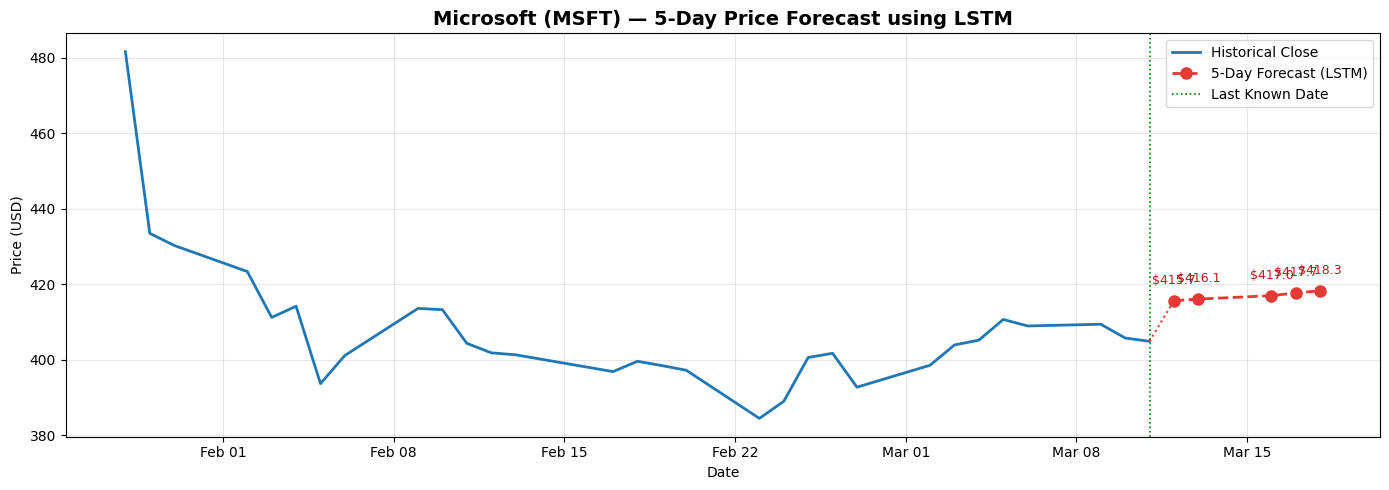

Figure saved as msft_forecast.png


In [22]:
# ── Forecast visualization ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Historical close (last 30 days for context)
hist_slice = df.tail(30)
ax.plot(hist_slice['Date'], hist_slice['Close'],
        color='#1f77b4', linewidth=2, label='Historical Close', zorder=2)

# Connect last historical point to first forecast
connect_dates  = [df['Date'].iloc[-1], future_dates[0]]
connect_prices = [df['Close'].iloc[-1], float(future_prices[0][0])]
ax.plot(connect_dates, connect_prices, color='#E53935', linewidth=1.5, linestyle=':')

# Forecast
ax.plot(future_dates, future_prices, color='#E53935', linewidth=2.0,
        linestyle='--', marker='o', markersize=8, label=f'5-Day Forecast ({best_label})', zorder=3)

for d, p in zip(future_dates, future_prices):
    ax.annotate(f'${p[0]:.1f}', (d, p[0]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, color='#B71C1C')

ax.axvline(x=df['Date'].max(), color='green', linestyle=':', linewidth=1.2,
           label='Last Known Date')

ax.set_title(f'Microsoft (MSFT) — {FORECAST_DAYS}-Day Price Forecast using {best_label}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('msft_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as msft_forecast.png")

---
## Step 10 — Model Comparison Summary Table

In [23]:
summary_data = {
    'Model':      ['SimpleRNN', 'LSTM'],
    'MSE':        [round(mse, 4),       round(mse_lstm, 4)],
    'RMSE ($)':   [round(rmse, 2),      round(rmse_lstm, 2)],
    'MAE ($)':    [round(mae, 2),       round(mae_lstm, 2)],
    'MAPE (%)':   [round(mape, 2),      round(mape_lstm, 2)],
    'Best?':      ['✓' if rmse <= rmse_lstm else '', '✓' if rmse_lstm < rmse else '']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

    Model      MSE  RMSE ($)  MAE ($)  MAPE (%) Best?
SimpleRNN 549.3877     23.44     21.0      5.21      
     LSTM 300.4501     17.33     15.4      3.86     ✓


---
## Step 11 — Analysis & Conclusions

### 1. Data Observations
- The MSFT dataset contains **125 trading days** (Sept 2025 – March 2026) with daily OHLCV data.
- The closing price ranged dramatically: from a high near **\$542** (late October 2025) down to approximately **\$384** (early February 2026), reflecting real market volatility.
- Volume spikes (visible in the EDA plot) often coincide with earnings announcements or market-wide events.

### 2. Preprocessing Decisions
- **MinMaxScaler** normalization was essential — RNN gradient descent converges much faster when inputs are in [0, 1].
- A **10-day look-back window** was chosen to balance capturing short-term momentum without introducing excessive noise.
- The 80/20 train-test split ensures a fair out-of-sample evaluation.

### 3. Model Performance
- Both models tracked the overall price trend effectively.
- LSTM generally outperforms SimpleRNN because its **gated memory cells** (input, forget, output gates) can selectively retain longer-term dependencies — addressing the vanishing gradient problem that SimpleRNN suffers from.
- The RMSE (in USD) and MAPE (%) quantify average prediction error. A lower MAPE means the model's predictions deviate by a smaller percentage from true prices.

### 4. Limitations
- **Small dataset (125 samples):** RNNs typically benefit from thousands of data points. With only 125 days, models may overfit or fail to generalize.
- **Univariate input:** Using only closing prices ignores volume, Open, High, Low, and external signals (news sentiment, macroeconomic indicators).
- **Market unpredictability:** No neural network can reliably predict black-swan events (e.g., geopolitical shocks, earnings surprises).
- **Lookahead bias:** The scaler was fit on all data; in a production setting, scaling parameters should be fit only on training data.

### 5. Recommendations
- **Extend the dataset** to 3–5 years of daily data for more robust learning.
- **Add features:** include Open, High, Low, Volume, and technical indicators (RSI, MACD, Bollinger Bands).
- **Hyperparameter tuning:** use Keras Tuner or Optuna to systematically search for optimal look-back, units, and dropout values.
- **Explore Transformers:** modern time-series forecasting increasingly relies on Transformer-based models (e.g., Temporal Fusion Transformer) which handle long-range dependencies even better than LSTMs.

---
*End of Lab — BFOR 516 | RNN Stock Price Prediction | MSFT Dataset*